In [16]:
## Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import optuna
from sklearn.model_selection import cross_val_score, KFold

In [2]:
from scipy.stats import pointbiserialr

In [2]:
%pip install xgboost


  Using cached xgboost-3.0.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.0.0-py3-none-win_amd64.whl (150.0 MB)


In [3]:
import xgboost as xgb

In [5]:
## Data

train = pd.read_csv('data/train.csv')

test = pd.read_csv('data/test.csv')

In [6]:
## Data Preprocessing

train['BMI'] = train['Weight'] / ((train['Height'] / 100) ** 2)

train['Sex_Encoded'] = train['Sex'].map({'male': 0, 'female': 1})

train['Intensity'] = train['Heart_Rate'] / train['Duration']


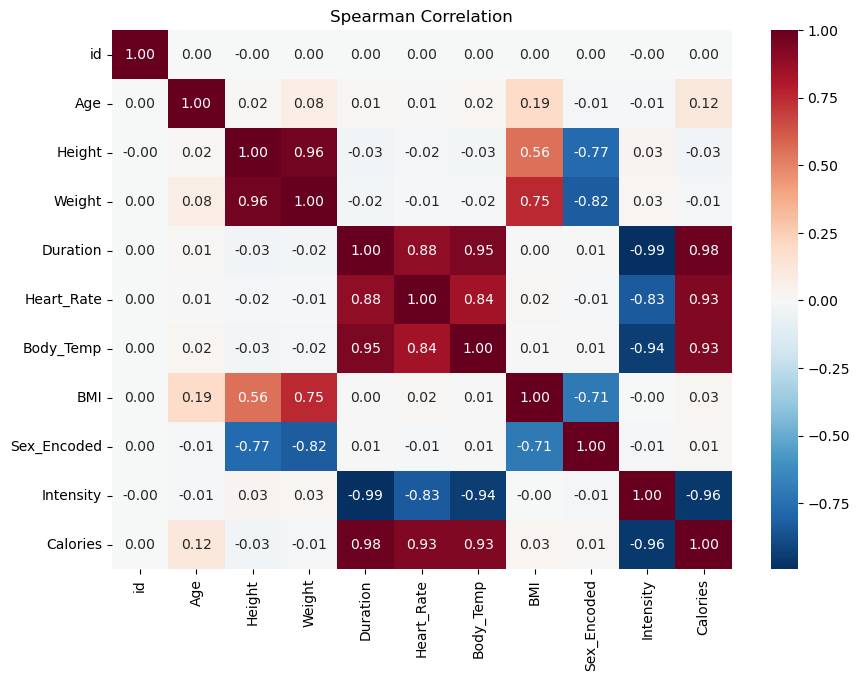

In [7]:
## Train Correlation

num_cols = train.select_dtypes(include = ["int64", "float64"]).columns.tolist()
num_cols.remove("Calories")

corr = train[num_cols + ["Calories"]].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Spearman Correlation")
plt.show()

In [9]:
## Splitting Data

X = train[['Sex_Encoded', 'Age', 'BMI', 'Duration', 'Heart_Rate', 'Body_Temp', 'Intensity']]
y = train['Calories']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

In [26]:
def objective(trial):
    # Hyperparameter search space
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 20)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    gamma = trial.suggest_float("gamma", 0, 5)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 1, 2)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)


    # Initialize K-Fold cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmsle_scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            min_child_weight=min_child_weight,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            gamma=gamma,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            max_delta_step=max_delta_step,
            random_state=42
        )

        # **Now we pass early_stopping_rounds properly**
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)],  verbose=False)
        
        preds = model.predict(X_val_fold)
        rmsle_scores.append(rmsle(y_val_fold, preds))

    return np.mean(rmsle_scores)


In [27]:
## Optuna Optimization

study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=50)

print("Best hyperparameters:", study.best_params)
print("Best RMSLE:", study.best_value)

[I 2025-05-14 09:56:44,111] A new study created in memory with name: no-name-78bd7dad-1a12-4b56-bb4c-53311ad2a8b4
[I 2025-05-14 09:56:57,531] Trial 0 finished with value: 0.9813324960622545 and parameters: {'n_estimators': 387, 'max_depth': 25, 'learning_rate': 0.013593550775612287, 'min_child_weight': 16, 'subsample': 0.6966246940371665, 'colsample_bytree': 0.8131252569843512, 'gamma': 2.0140867763935395, 'reg_alpha': 0.22811440261998295, 'reg_lambda': 1.041129476691982, 'max_delta_step': 1}. Best is trial 0 with value: 0.9813324960622545.
[I 2025-05-14 09:57:34,746] Trial 1 finished with value: 0.8102976558286411 and parameters: {'n_estimators': 196, 'max_depth': 24, 'learning_rate': 0.02568869477222562, 'min_child_weight': 6, 'subsample': 0.7817955467485644, 'colsample_bytree': 0.7889860462035831, 'gamma': 3.416644962678795, 'reg_alpha': 0.6108353501347438, 'reg_lambda': 1.021394212280482, 'max_delta_step': 5}. Best is trial 1 with value: 0.8102976558286411.
[I 2025-05-14 09:58:16,0

Best hyperparameters: {'n_estimators': 469, 'max_depth': 11, 'learning_rate': 0.02099501168867094, 'min_child_weight': 9, 'subsample': 0.6419912836346608, 'colsample_bytree': 0.7156737905332802, 'gamma': 2.284804493628048, 'reg_alpha': 0.749160943031064, 'reg_lambda': 1.0083321878114324, 'max_delta_step': 0}
Best RMSLE: 0.06429791305763059


In [28]:
## Optimized Model

opt_xgb_model = xgb.XGBRegressor(**study.best_params, random_state=42)

nonOP_xgb_model = xgb.XGBRegressor(random_state=42)

In [29]:
## Fitting Model

opt_xgb_model.fit(X_train, y_train)

nonOP_xgb_model.fit(X_train, y_train) 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [30]:
## Make Predictions

train_predictions = opt_xgb_model.predict(X_test)

nonOP_train_predictions = nonOP_xgb_model.predict(X_test)

In [31]:
nonOP_train_predictions = np.maximum(0, nonOP_train_predictions)

In [32]:
## Root Mean Squared Logarithmic Error

msle = mean_squared_log_error(y_test, train_predictions)

rmsle = np.sqrt(msle)

print("RMSLE:", rmsle)

nonOP_msle = mean_squared_log_error(y_test, nonOP_train_predictions)

nonOP_rmsle = np.sqrt(nonOP_msle)

print("NON Optimized RMSLE:", nonOP_rmsle)

RMSLE: 0.06350821151610792
NON Optimized RMSLE: 0.06913421115769931
